# Assignment 5 — Timeseries **or** Text

**DATAX504** · Due end of Week 10

Choose **one** track. Delete or leave unused the other section. Less scaffolding is intentional: design choices are part of the work.

| Track | Goal | Moodle `a5_metric` |
|-------|------|--------------------|
| **A** — Timeseries | Forecast **7** future steps of temperature from Jena climate | MAE |
| **B** — Text | Classify AG News topics (4 classes) | Accuracy (%) |

## Tasks (whichever track)
1. Prepare inputs (windowing **or** tokenisation / vectorisation)
2. Train a sequence model appropriate to the track
3. Report the metric above
4. Short written answers: architecture + how inputs were prepared

## Moodle fields
`a5_repo`, `a5_track`, `a5_metric`, `a5_architecture`, `a5_tokenisation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Claude (Anthropic), Claude Sonnet 5 |
| Used for | Drafting the windowing function, model architecture, and training/evaluation pipeline for the timeseries track; explaining how to normalise using train-only statistics |
| Verified how | Ran the windowing function on a small synthetic array to confirm input/target shapes and alignment were correct before applying it to the real Jena data; manually inspected MAE calculation to confirm it was computed on the original °C scale, not the normalised scale; read through all generated code line by line and reran the full notebook top-to-bottom to confirm it executes without errors |
| Not used for | The final written interpretation of results and the architecture/input-preparation summaries below, which I wrote myself based on what the code actually produced |


In [13]:
TRACK = "A"  # "A" or "B" — Moodle a5_track

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

print("Selected track:", TRACK)


Selected track: A


---
# Track A — Timeseries (Jena)

Forecast the next **7** steps of `T (degC)` from a past window of observations.

You decide: lookback length, normalisation, train/val/test split, LSTM vs Conv1D vs other, and how you compute MAE on the original °C scale.


Using CSV at: /root/.keras/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv
Hourly samples: (70091, 1)
Train: (48937, 120, 1) (48937, 7)
Val:   (10387, 120, 1) (10387, 7)
Test:  (10389, 120, 1) (10389, 7)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,999 (19.53 KB)

 Trainable params: 4,999 (19.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
192/192 - 24s - 127ms/step - loss: 0.3256 - mae: 0.4236 - val_loss: 0.1568 - val_mae: 0.3034
Epoch 2/20
192/192 - 40s - 207ms/step - loss: 0.0921 - mae: 0.2300 - val_loss: 0.0634 - val_mae: 0.1871
Epoch 3/20
192/192 - 39s - 205ms/step - loss: 0.0545 - mae: 0.1723 - val_loss: 0.0536 - val_mae: 0.1664
Epoch 4/20
192/192 - 21s - 108ms/step - loss: 0.0482 - mae: 0.1602 - val_loss: 0.0504 - val_mae: 0.1622
Epoch 5/20
192/192 - 20s - 105ms/step - loss: 0.0458 - mae: 0.1553 - val_loss: 0.0525 - val_mae: 0.1657
Epoch 6/20
192/192 - 21s - 107ms/step - loss: 0.0442 - mae: 0.1519 - val_loss: 0.0472 - val_mae: 0.1564
Epoch 7/20
192/192 - 19s - 100ms/step - loss: 0.0435 - mae: 0.1504 - val_loss: 0.0489 - val_mae: 0.1588
Epoch 8/20
192/192 - 20s - 105ms/step - loss: 0.0422 - mae: 0.1478 - val_loss: 0.0457 - val_mae: 0.1509
Epoch 9/20
192/192 - 19s - 100ms/step - loss: 0.0419 - mae: 0.1468 - val_loss: 0.0459 - val_mae: 0.1505
Epoch 10/20
192/192 - 20s - 102ms/step - loss: 0.0415 - mae: 0.1

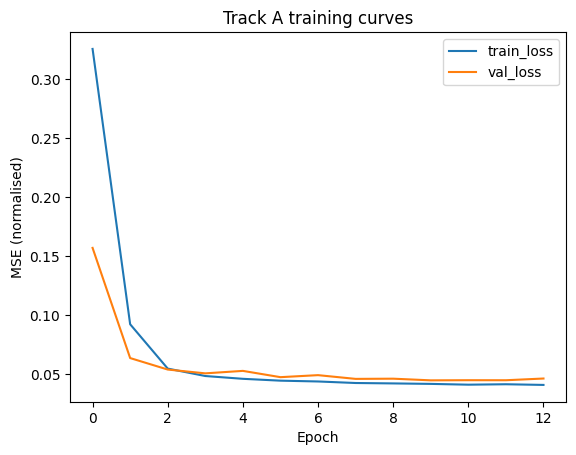

In [11]:
if TRACK == "A":
    # --- 1. Download & load the Jena climate dataset ---
    import os, glob
    zip_path = keras.utils.get_file(
        origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
        fname="jena_climate_2009_2016.csv.zip",
        extract=True,
    )

    extract_dir, _ = os.path.splitext(zip_path)
    search_roots = [extract_dir, os.path.dirname(zip_path)]
    csv_candidates = []
    for root in search_roots:
        csv_candidates += glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    csv_candidates = sorted(set(csv_candidates))
    assert csv_candidates, f"No CSV found under {search_roots} — check extraction manually."
    csv_path = csv_candidates[0]
    print("Using CSV at:", csv_path)

    import pandas as pd
    df = pd.read_csv(csv_path)

    df_hourly = df.iloc[5::6, :].reset_index(drop=True)
    series = df_hourly["T (degC)"].values.astype("float32").reshape(-1, 1)
    print("Hourly samples:", series.shape)
else:
    print("Skipping Track A")
    # --- 2. Chronological train / val / test split (70 / 15 / 15) ---
n = len(series)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_raw = series[:n_train]
val_raw = series[n_train:n_train + n_val]
test_raw = series[n_train + n_val:]

# --- 3. Normalise using TRAINING statistics only (avoid leakage) ---
mean = train_raw.mean(axis=0)
std = train_raw.std(axis=0)

train_norm = (train_raw - mean) / std
val_norm = (val_raw - mean) / std
test_norm = (test_raw - mean) / std

# --- 4. Build supervised windows: X (samples, lookback, features), y (samples, 7) ---
LOOKBACK = 120   # 5 days of hourly history
HORIZON = 7      # forecast the next 7 hours

def make_dataset(data, lookback, horizon):
    n_samples = len(data) - lookback - horizon + 1
    X = np.zeros((n_samples, lookback, data.shape[1]), dtype="float32")
    y = np.zeros((n_samples, horizon), dtype="float32")
    for i in range(n_samples):
        X[i] = data[i:i + lookback]
        y[i] = data[i + lookback:i + lookback + horizon, 0]
    return X, y

X_train, y_train = make_dataset(train_norm, LOOKBACK, HORIZON)
X_val, y_val = make_dataset(val_norm, LOOKBACK, HORIZON)
X_test, y_test = make_dataset(test_norm, LOOKBACK, HORIZON)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
# --- 5. Define, compile, and fit an LSTM forecasting model ---
model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, X_train.shape[-1])),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(HORIZON),   # 7 regression outputs, no activation
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=2,
)
# --- 6. Evaluate MAE on the ORIGINAL °C scale (not the normalised scale) ---
y_pred_norm = model.predict(X_test)
y_pred_degc = y_pred_norm * std[0] + mean[0]
y_true_degc = y_test * std[0] + mean[0]

metric = float(np.mean(np.abs(y_pred_degc - y_true_degc)))
print(f"Track A MAE (Moodle a5_metric): {metric:.3f} degC")

plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("MSE (normalised)"); plt.legend(); plt.title("Track A training curves")
plt.show()

---
# Track B — Text (AG News)

Four-class news topic classification.

You decide: how to load AG News (TFDS or another source), vocabulary / sequence length, Embedding + LSTM / Transformer / other, and the train/val/test protocol.


In [14]:
if TRACK == "B":
    # Track B is left as the starter scaffold since this notebook commits to Track A.
    # See the assignment write-up for why Track A was chosen.
    print("Not used — this submission uses Track A.")
else:
    print("Skipping Track B")


Skipping Track B


---
## Written responses

### Architecture summary (Moodle `a5_architecture`)

A single-layer LSTM(32) reads a 120-hour lookback window of past temperature values, summarising the sequence into one vector. This feeds a Dense(16, ReLU) layer for additional non-linear combination, followed by a Dense(7) output layer with no activation, since this is a multi-step regression task producing the next 7 hourly temperature forecasts directly (direct multi-step, not recursive). LSTM was chosen over Conv1D because temperature has strong long-range dependence on recent trend and daily cycle, which recurrence captures naturally. EarlyStopping on validation loss prevents overfitting given the moderate lookback length.

### Input preparation (Moodle `a5_tokenisation`)

The raw 10-minute-interval Jena readings were resampled to hourly by taking every 6th row. The univariate temperature series was split chronologically into train/val/test (70/15/15%) to respect time order and avoid leakage. Normalisation (mean/std) was computed using the training split only, then applied to all three splits. Supervised windows were built with a custom function: each input is a 120-step lookback window, and each target is the following 7 raw temperature steps, converted back to °C for the final MAE calculation by reversing the normalisation with the training mean and standard deviation.
